In [47]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
spotify_data1 = pd.read_json("StreamingHistory_music_0.json")
spotify_data1.to_csv("StreamingHistory_music_0.csv")
spotify_data1= spotify_data1.head(150)
spotify_data1.describe()

,msPlayed
count,150.000000
mean,91491.960000
std,97028.211348
min,0.000000
25%,3058.750000
50%,48998.000000
75%,183113.500000
max,460783.000000


In [3]:
spotify_data1.dtypes

endTime       object
artistName    object
trackName     object
msPlayed       int64
dtype: object

In [4]:
#convert endTime to datetime type
spotify_data1['endTime'] = pd.to_datetime(spotify_data1['endTime'])
spotify_data1.dtypes

endTime       datetime64[ns]
artistName            object
trackName             object
msPlayed               int64
dtype: object

In [5]:
spotify_data1['msPlayed'].sum()

13723794

In [6]:
spotify_data1['minutesPlayed'] = spotify_data1['msPlayed']/6000
spotify_data1


,endTime,artistName,trackName,msPlayed,minutesPlayed
0,2024-09-27 01:31:00,GIVĒON,World We Created,15360,2.560000
1,2024-09-27 01:37:00,GIVĒON,World We Created,195439,32.573167
2,2024-09-27 01:41:00,Avenoir,TMW,1230,0.205000
3,2024-09-27 01:41:00,Daniel Caesar,Get You (feat. Kali Uchis),36636,6.106000
4,2024-09-27 01:41:00,A$AP Ferg,"Dreams, Fairytales, Fantasies (feat. Brent Fai...",222986,37.164333
...,...,...,...,...,...
145,2024-09-29 04:16:00,Montell Fish,Fall in Love with You.,132000,22.000000
146,2024-09-29 04:20:00,Frank Ocean,Thinkin Bout You,181271,30.211833
147,2024-09-29 04:23:00,The Weeknd,What You Need,206421,34.403500
148,2024-09-29 04:23:00,Suki Waterhouse,Good Looking,905,0.150833


In [7]:
top_artist=spotify_data1.groupby(by='artistName')['msPlayed'].sum().sort_values(ascending=False)
top_artist

artistName
SZA            1570618
GIVĒON         1146138
Disclosure     1119684
Rema           1006123
A$AP Ferg       892057
                ...   
Eyedress           952
Tom Odell          743
Labrinth           534
Will Paquin        174
Darondo              0
Name: msPlayed, Length: 68, dtype: int64

In [8]:
top_tracks = spotify_data1.groupby('trackName')['msPlayed'].sum().sort_values(ascending=False).head(10)
top_tracks

trackName
Latch                                                               1119684
Dreams, Fairytales, Fantasies (feat. Brent Faiyaz & Salaam Remi)     892057
Anything                                                             811612
New Person, Same Old Mistakes                                        581938
World We Created                                                     556958
How - demo                                                           554033
my mine                                                              524455
Iris                                                                 436768
Woman                                                                411648
Garden Kisses                                                        390810
Name: msPlayed, dtype: int64

<Axes: ylabel='artistName'>

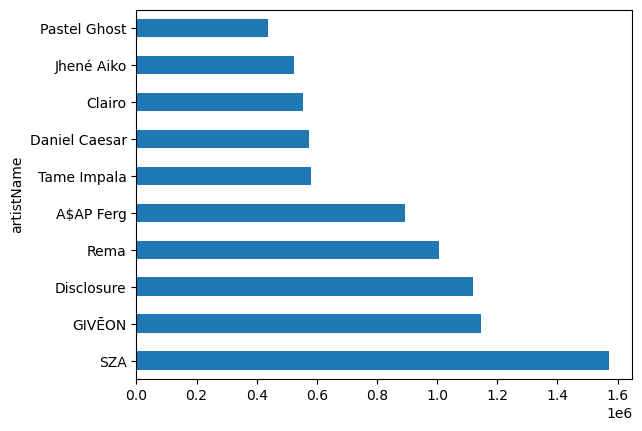

In [9]:
top_artist.head(10).plot(kind='barh')

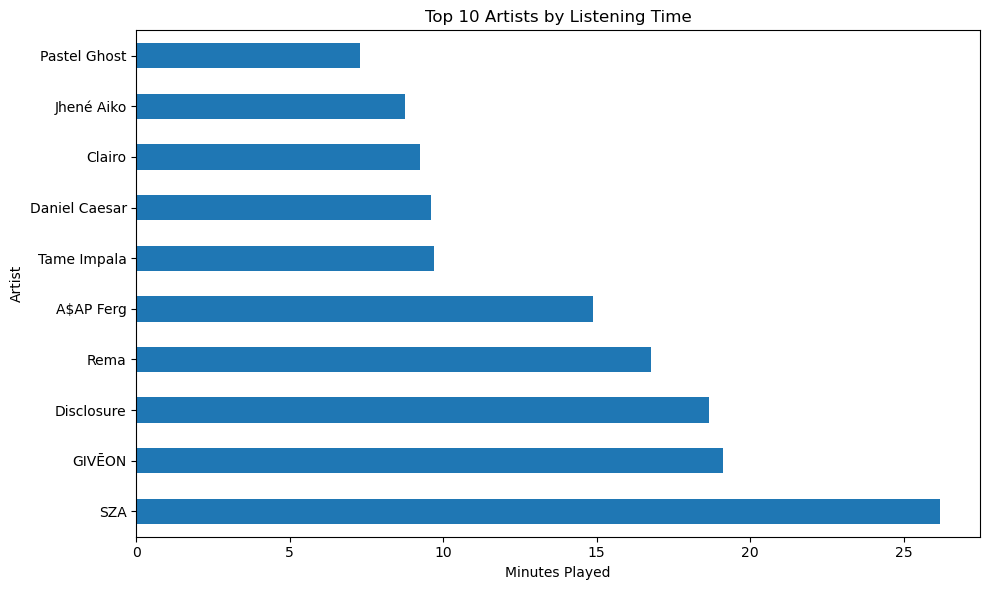

In [10]:
plt.figure(figsize=(10,6))
(top_artist.head(10) / 60000).plot(kind='barh')
plt.xlabel('Minutes Played')
plt.ylabel('Artist')
plt.title('Top 10 Artists by Listening Time')
plt.tight_layout()
plt.show()

In [11]:
#Extract Date
spotify_data1['date']=spotify_data1['endTime'].dt.date

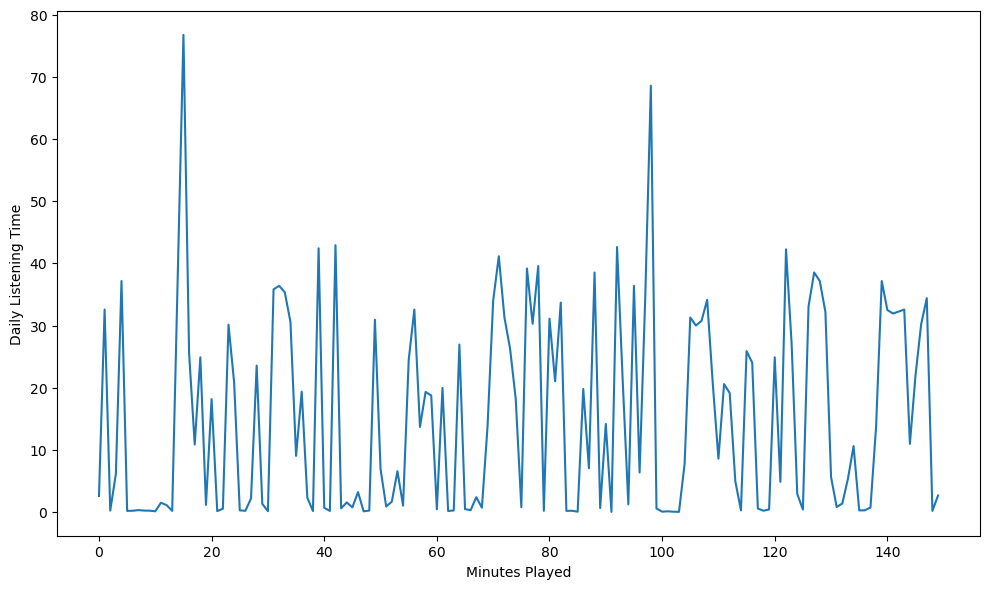

In [12]:
plt.figure(figsize=(10,6))
(spotify_data1['minutesPlayed'].plot(kind='line'))
plt.xlabel('Minutes Played')
plt.ylabel('Daily Listening Time')
plt.tight_layout()
plt.show()

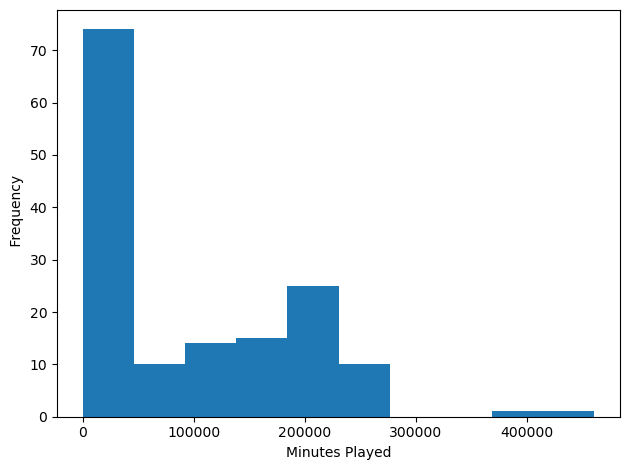

In [13]:
spotify_data1['msPlayed'].plot(kind='hist')
plt.xlabel('Minutes Played')
plt.ylabel(' Frequency')
plt.tight_layout()
plt.show()

In [14]:
#Intermediate

In [15]:
spotify_data1['Hour']= spotify_data1['endTime'].dt.hour
spotify_data1['Weekday']= spotify_data1['endTime'].dt.weekday
spotify_data1['Day']= spotify_data1['endTime'].dt.date


In [16]:
hourly= spotify_data1.groupby('Hour')['msPlayed'].sum()
hourly

Hour
0     1383045
1     1869981
2     2418470
3     3014705
4     1899944
5     1834691
15     126489
16      14002
18     149025
19     645982
20     183586
23     183874
Name: msPlayed, dtype: int64

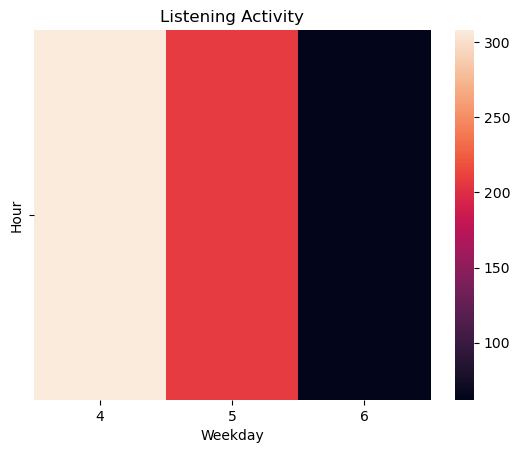

In [17]:
pivot= spotify_data1.pivot_table( values= 'Hour', columns = 'Weekday', aggfunc='sum')
plt.figsize=(10,16)
sns.heatmap(pivot);
plt.title('Listening Activity');


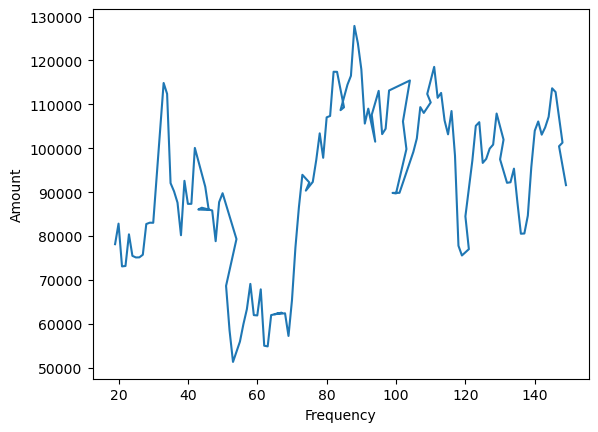

In [18]:
spotify_data1 = spotify_data1.sort_values('endTime')
spotify_data1['rolling20']= spotify_data1['msPlayed'].rolling(20).mean()
spotify_data1['rolling20'].plot();
plt.xlabel('Frequency');
plt.ylabel('Amount');

In [19]:
spotify_data1['isSkip'] =  (spotify_data1['msPlayed']< 2000).astype(int)
count = sum(1 for i in spotify_data1['isSkip'] if i == 1)
print(count)

33


In [20]:
spotify_data1['cumSum']=spotify_data1.groupby('artistName')['msPlayed'].cumsum()

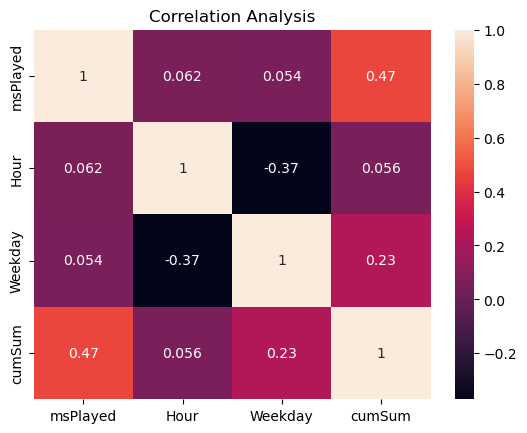

In [21]:
# Correlations
corr = spotify_data1[['msPlayed','Hour' , 'Weekday' , 'cumSum']].corr()
sns.heatmap(corr, annot=True);
plt.figsize=(10,16)
plt.title('Correlation Analysis');

In [39]:
# import models and sklearn
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, accuracy_score, confusion_matrix,ConfusionMatrixDisplay
from sklearn.cluster import KMeans

In [34]:
X = spotify_data1[['Hour','Weekday','msPlayed']]
y = spotify_data1['cumSum']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)
model = LinearRegression()
model.fit(X_train,y_train)
pred=model.predict(X_test)
score_r2= r2_score(y_test, pred)
score_r2


0.24460004642197797

In [53]:
X = spotify_data1[['Hour','Weekday','msPlayed']]
y = spotify_data1['isSkip']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)
clf = LogisticRegression()
clf.fit(X_train,y_train)
raw_pred=clf.predict(X_test)
pred = (raw_pred > 0.5).astype(int)
accurate = accuracy_score(y_test,pred)

print("This is the accuracy score:",accurate)
print("This is the confusion matrix:",cm)
cm = confusion_matrix(y_test,pred)


cm = confusion_matrix(y_test, pred)

print(raw_pred)
print(np.array(y_test))
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
print(rf.score(X_test, y_test))



# disp = ConfusionMatrixDisplay(confusion_matrix=cm)
# disp.plot(cmap='Blues')
# plt.title("Skip Prediction Confusion Matrix")
# plt.show()



This is the accuracy score: 1.0
This is the confusion matrix: [[25  0]
 [ 0  5]]
[0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1 1 1 1 1 0 0 0 0]
[0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1 1 1 1 1 0 0 0 0]
1.0


In [ ]:
features = spotify_data1[['Hour','Weekday','msPlayed']]
kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(features)
spotify_data1['cluster'] = labels

plt.figure(figsize=(10,6))
plt.scatter(spotify_data1['Hour'], spotify_data1['msPlayed'], c=labels, alpha=0.5)
plt.xlabel('Hour')
plt.ylabel('msPlayed')
plt.title('KMeans Clusters of Listening Behavior')
plt.show()

In [ ]:

spotify_data1['cumSum']=spotify_data1.groupby('artistName')['msPlayed'].cumsum()
# df_unique = df.drop_duplicates(subset='artistName', keep='last')
spotify_data1u = spotify_data1.drop_duplicates(subset='artistName', keep='last')
spotify_data1u.isna().sum()

   

In [ ]:
spotify_data1u.plot(x='cumSum' , y='msPlayed', figsize=(30,10),kind='bar');

In [ ]:
fig, (ax0,ax1) = plt.subplots(nrows=2,ncols=1,figsize=(20,30))
ax0.scatter( x = spotify_data1u['cumSum'],
            y= spotify_data1u['msPlayed']);
ax0.set( ylabel = 'Minutes played');
ax0.axhline(y= spotify_data1u['msPlayed'].mean(),
           color = 'g',
           linestyle='--');
ax1.scatter(x =spotify_data1u['cumSum'],
            y = spotify_data1u['artistName']);
ax1.set(xlabel = 'Minutes played',
        ylabel='Artist Name');
# ax1.axhline(y=spotify_data1u['cumSum'].mean())
fig.suptitle("Ife's spotify average", fontsize=40, fontweight='bold')

In [ ]:
plt.figure(figsize =(14,12));
sns.lineplot(spotify_data1u, x= 'msPlayed', y ='artistName');

In [ ]:
plt.figure(figsize=(14, 32));
sns.histplot(data=spotify_data1u, x='msPlayed', y='artistName');
plt.yticks(fontsize=7);
# plt.tight_layout()
